## Objetivo del taller

Investigar la percepción del color desde el punto de vista humano y computacional, y representar visualmente las diferencias entre modelos de color. El objetivo es comprender cómo los distintos espacios de color afectan la interpretación visual y cómo pueden aplicarse transformaciones para simular condiciones específicas.

## Desarollo

A continuación, se seleccionará una imagen y se moverá su espacio de color. Para ello, usaremos las siguientes librerías.

In [ ]:
import cv2                       # OpenCV (opencv-python)
import matplotlib.pyplot as plt  # Matplotlib (para visualización)
import colorsys                  # Conversión de espacios de color (RGB/HSV/HLS)
from skimage import color        # scikit-image (para procesamiento de imágenes)
import numpy as np               # NumPy (arrays y operaciones numéricas)

In [ ]:
# 1. Cargar imagen con OpenCV (en BGR por defecto)
ImagenPrincipal = cv2.imread('/content/MichiHarol.jpg')                # Imagen principal cv2 la trae en formato BGR
ImagenPrincipalRGB = cv2.cvtColor(ImagenPrincipal, cv2.COLOR_BGR2RGB)  # Convertimos a RGB
ImagenPrincipalHSV = cv2.cvtColor(ImagenPrincipalRGB, cv2.COLOR_BGR2HSV)  # Convertimos a HSV

In [ ]:
# 2. Cargar imagen para formato CIE Lab
ImagenPrincipal32B = ImagenPrincipalRGB.astype(np.float32) / 255.0
ImagenPrincipalLab = color.rgb2lab(ImagenPrincipal32B)


Con la imagenes es sus formatos prosedemos a mostrarlas


(np.float64(-0.5), np.float64(1199.5), np.float64(1599.5), np.float64(-0.5))

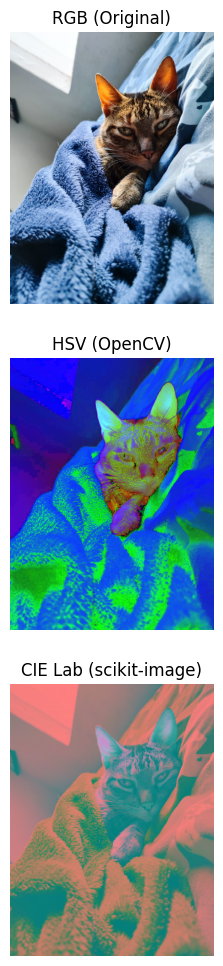

In [ ]:
# 3. Primera Visualización
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# 3.1 Mostrar imágenes
axes[0].imshow(ImagenPrincipalRGB)
axes[0].set_title('RGB (Original)')
axes[0].axis('off')

axes[1].imshow(ImagenPrincipalHSV)
axes[1].set_title('HSV (OpenCV)')
axes[1].axis('off')

# CIE Lab necesita ajuste para visualización (normalizar canales)
ImagenPrincipalLabNormalizada = (ImagenPrincipalLab + [0, 128, 128]) / [100, 255, 255]  # Escalar L: [0,100], a/b: [-127,127]
axes[2].imshow(ImagenPrincipalLabNormalizada)
axes[2].set_title('CIE Lab (scikit-image)')
axes[2].axis('off')

Realizaremos los cambios para verlas en sus canales individuales tanto para HSV como para CIE lab

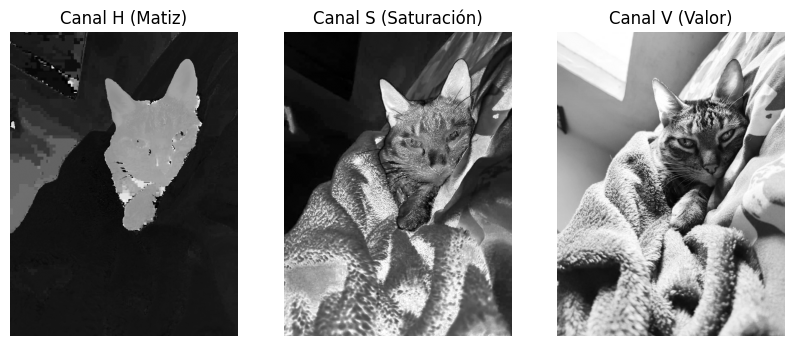

In [ ]:
# Extraer canales H S V
canal_H = ImagenPrincipalHSV[:, :, 0]  # 0 = Canal H
canal_S = ImagenPrincipalHSV[:, :, 1]  # 0 = Canal S
canal_V = ImagenPrincipalHSV[:, :, 2]  # 0 = Canal V

# Mostrar el canal H S V en escala de grises
# 4. Primera Visualización
fig, axes = plt.subplots(1, 3, figsize=(10, 12))

# 4.1 Mostrar imágenes
axes[0].imshow(canal_H, cmap='gray')
axes[0].set_title('Canal H (Matiz)')

axes[1].imshow(canal_S, cmap='gray')
axes[1].set_title('Canal S (Saturación)')

axes[2].imshow(canal_V, cmap='gray')
axes[2].set_title('Canal V (Valor)')

for ax in axes:
    ax.axis('off')
plt.show()

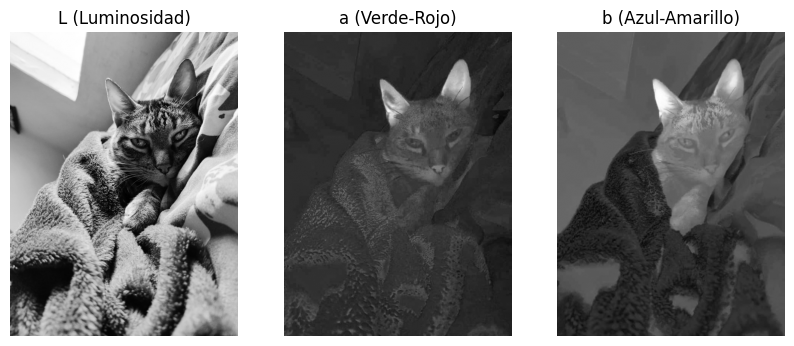

In [ ]:
# Extraer canales CIE lab
canal_L = ImagenPrincipalLab[:, :, 0]
canal_a = ImagenPrincipalLab[:, :, 1]
canal_b = ImagenPrincipalLab[:, :, 2]

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(10, 12))

axes[0].imshow(canal_L, cmap='gray', vmin=0, vmax=100)
axes[0].set_title('L (Luminosidad)')

axes[1].imshow((canal_a + 128) / 255, cmap='gray')
axes[1].set_title('a (Verde-Rojo)')

axes[2].imshow((canal_b + 128) / 255, cmap='gray')
axes[2].set_title('b (Azul-Amarillo)')
for ax in axes:
    ax.axis('off')
plt.show()

Daltonismo (protanopía, deuteranopía) con funciones de simulación o manipulación de matrices de color.

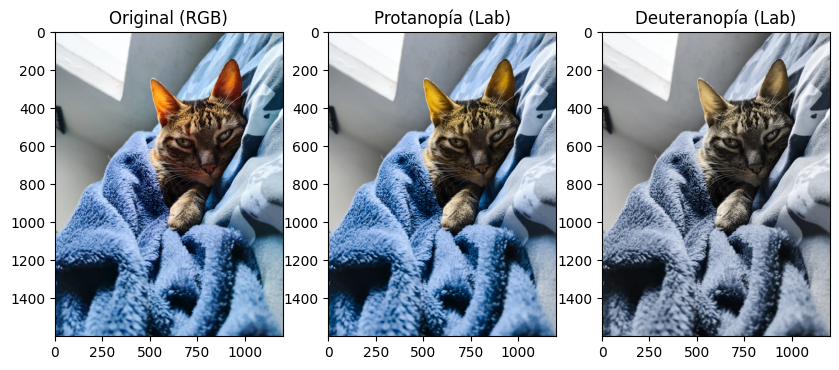

In [ ]:
# Simular protanopía (reducir canal a)
img_lab_protanopia = ImagenPrincipalLab.copy()
img_lab_protanopia[:, :, 1] *= 0.3  # Reducir información verde-rojo

# Simular deuteranopía (reducir canal a y ajustar b)
img_lab_deuteranopia = ImagenPrincipalLab.copy()
img_lab_deuteranopia[:, :, 1] *= 0.1
img_lab_deuteranopia[:, :, 2] *= 0.5

# Convertir de vuelta a RGB
img_protanopia_lab = color.lab2rgb(img_lab_protanopia)
img_deuteranopia_lab = color.lab2rgb(img_lab_deuteranopia)

# Mostrar resultados
plt.figure(figsize=(10, 12))
plt.subplot(131), plt.imshow(ImagenPrincipalRGB), plt.title('Original (RGB)')
plt.subplot(132), plt.imshow(img_protanopia_lab), plt.title('Protanopía (Lab)')
plt.subplot(133), plt.imshow(img_deuteranopia_lab), plt.title('Deuteranopía (Lab)')
plt.show()

Reducción de brillo o contraste para simular entornos de baja luz.

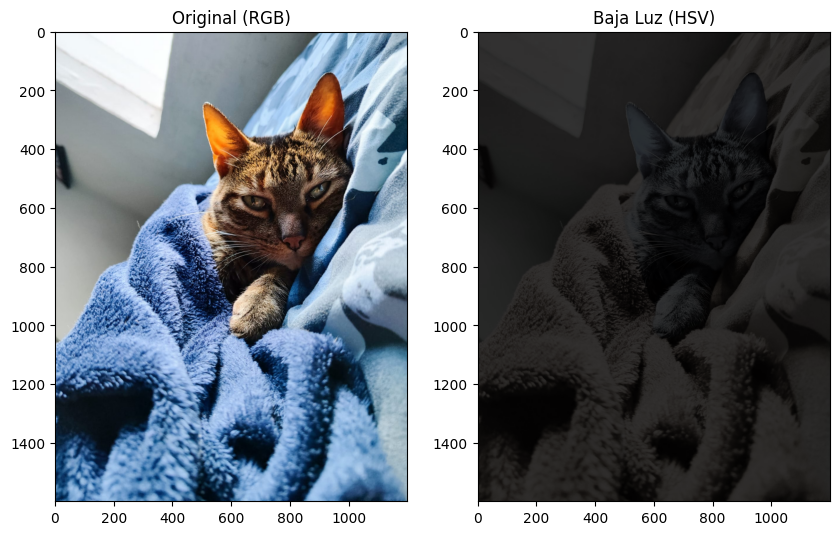

In [ ]:
# Reducir brillo (canal V)
img_hsv_low_light = ImagenPrincipalHSV.copy()
img_hsv_low_light[:, :, 2] = img_hsv_low_light[:, :, 2] * 0.2  # Reducir a 20%

# Reducir contraste (canal S)
img_hsv_low_light[:, :, 1] = img_hsv_low_light[:, :, 1] * 0.2  # Reducir saturación

# Convertir de vuelta a RGB
img_low_light = cv2.cvtColor(img_hsv_low_light, cv2.COLOR_HSV2RGB)

# Mostrar resultados
plt.figure(figsize=(10, 12))
plt.subplot(121), plt.imshow(ImagenPrincipalRGB), plt.title('Original (RGB)')
plt.subplot(122), plt.imshow(img_low_light), plt.title('Baja Luz (HSV)')
plt.show()

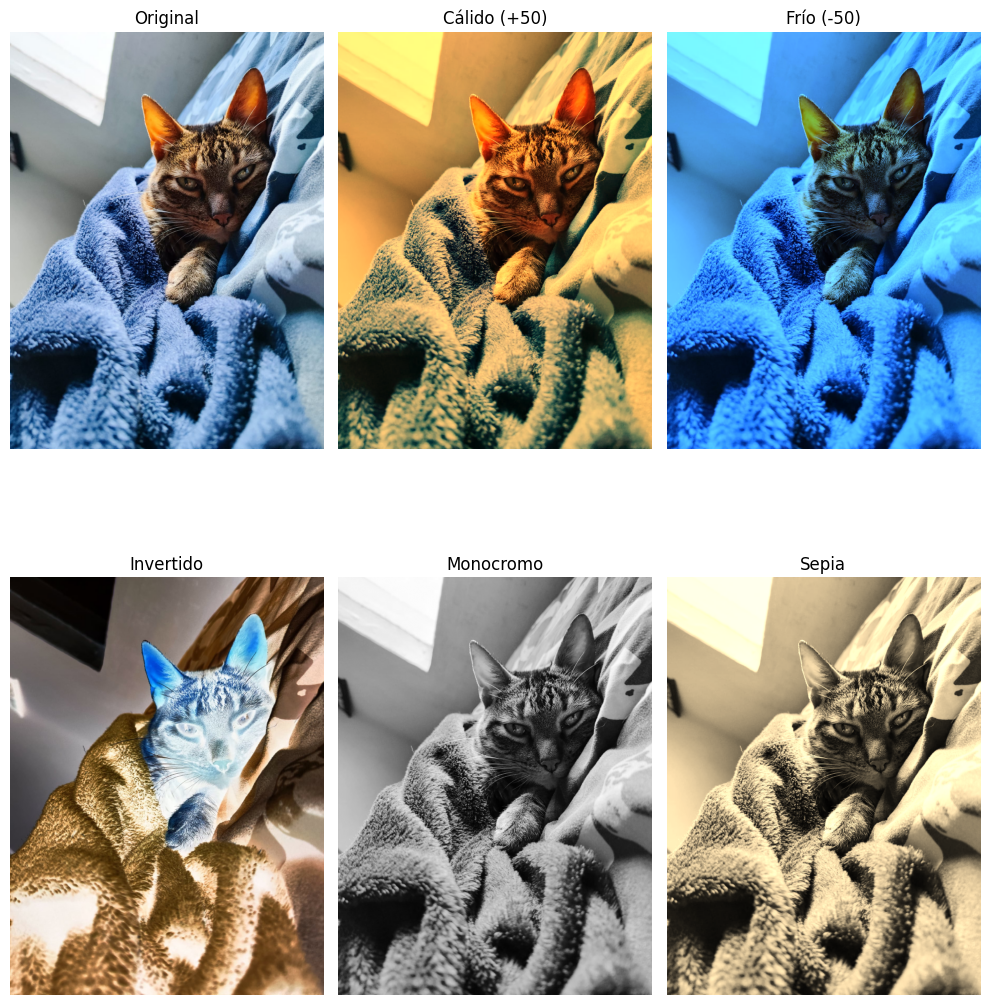

In [ ]:
# FILTROS

def adjust_color_temp(img, temp):
    """Ajusta temperatura de color (-100 a 100)."""
    temp = np.clip(temp / 100, -1, 1)
    img = img.astype(np.float32)
    img[:, :, 0] = np.clip(img[:, :, 0] * (1 + temp), 0, 255)  # Canal B
    img[:, :, 2] = np.clip(img[:, :, 2] * (1 - temp), 0, 255)   # Canal R
    return img.astype(np.uint8)

def invert_colors(img):
    """Invierte los colores."""
    return 255 - img if img.dtype == np.uint8 else 1.0 - img

def grayscale_luminance(img):
    """Convierte a gris con pesos de luminosidad."""
    return np.dot(img[..., :3], [0.299, 0.587, 0.114]).astype(np.uint8)

def apply_sepia(img):
    """Aplica efecto sepia."""
    sepia_matrix = np.array([
        [0.393, 0.769, 0.189],
        [0.349, 0.686, 0.168],
        [0.272, 0.534, 0.131]
    ])
    return np.clip(np.dot(img, sepia_matrix.T), 0, 255).astype(np.uint8)

# APLICAR FILTROS

img_warm = adjust_color_temp(ImagenPrincipalRGB, 50)    # Cálido (+50)
img_cold = adjust_color_temp(ImagenPrincipalRGB, -50)   # Frío (-50)
img_inverted = invert_colors(ImagenPrincipalRGB)
img_grayscale = grayscale_luminance(ImagenPrincipalRGB)
img_sepia = apply_sepia(ImagenPrincipalRGB)


# VISUALIZACIÓN (Todos los filtros)

plt.figure(figsize=(10, 12))

# Fila 1: Original y Temperatura
plt.subplot(2, 3, 1), plt.imshow(ImagenPrincipalRGB), plt.title('Original'), plt.axis('off')
plt.subplot(2, 3, 2), plt.imshow(img_warm), plt.title('Cálido (+50)'), plt.axis('off')
plt.subplot(2, 3, 3), plt.imshow(img_cold), plt.title('Frío (-50)'), plt.axis('off')

# Fila 2: Inversión, Monocromo y Sepia
plt.subplot(2, 3, 4), plt.imshow(img_inverted), plt.title('Invertido'), plt.axis('off')
plt.subplot(2, 3, 5), plt.imshow(img_grayscale, cmap='gray'), plt.title('Monocromo'), plt.axis('off')
plt.subplot(2, 3, 6), plt.imshow(img_sepia), plt.title('Sepia'), plt.axis('off')

plt.tight_layout()
plt.show()